# Churn at Fitness App

## Data Validation
The dataset has 3 csv-files: 
- da_app_account_info
- da_app_customer_support
- da_app_user_activity

### 1) account_info

The da_app_account_info file contains 400 rows and 6 columns before cleaning and validataion. I have validated and cleaned all the columns against the criteria in the dataset table:

- **customer_id:** String in format “C10001”. Standardized by removing the starting letter to align with user_id in other datasets.
- **email:** Unique email adresses for each user, without duplicates or missing values. No cleaning is needed.
- **state:** 50 categories (states of USA) without missing value. No cleaning is needed.
- **plan:** 4 categories without missing values. No cleaning is needed.
- **plan_list_price:** Numeric values without negative or missing values. Consistent with plan tiers. No cleaning is needed.
- **churn_status:** "Y" (Yes) or missing value. Missing values are replaced with "N", indicating "No".

After the data validation and cleaning, the dataset renamed as **account_info**, contains 400 rows and 6 columns without missing values or duplicates.

### 2) customer_support

The da_app_customer_support file contains 918 rows and 7 columns before cleaning and validataion. I have validated and cleaned all the columns against the criteria in the dataset table:

- **ticket_time:** Time in Pacific time, without duplicates or missing values. Data type is changed to _datetime64_.
- **user_id:** Numeric values without missing values. Used as join key. No cleaning is needed.
- **channel:** 4 categories including "-" as not specified. No missing values, no cleaning is needed.
- **topic:** 4 categories without missing values. No cleaning is needed.
- **resolution_time_hours:** Numeric and positive values, no missing values. No cleaning is needed.
- **state:** Binary indicator, interpreted as ticket status. No missing values, no cleaning is needed.
- **comments:** 46 free text. Not used quantitatively.

After the data validation and cleaning, the dataset renamed as **customer_support**, contains 918 rows and 7 columns without missing values or duplicates, except "comments" column.

### 3) user_activity

The da_app_user_activity file contains 445 rows and 3 columns before cleaning and validataion. I have validated and cleaned all the columns against the criteria in the dataset table:

- **event_time:**  Time in Pacific time, without duplicates or missing values. Data type is changed to _datetime64_.
- **user_id:** Numeric values without missing values. Used as join key. No cleaning is needed.
- **event_type:** 4 categories without missing values. No cleaning is needed.

After the data validation and cleaning, the dataset renamed as **user_activity**, contains 445 rows and 3 columns without missing values or duplicates.


## Customer Plan Choices and Engagement Patterns
We had a total of 400 users, spanning Free, Basic, Pro and Enterprise plans, using our app to watch video, read articles, track their workout and share it. The numbers show that we lost almost 30 percent of our users over the past two quarters.

![churn percentage](chart01_churn_percentage.png)

In order to determine the what’s driving churn, we should first understand the behaviour and choices of our users. Majority of our users have subscribed to the Free and Basic plan, however number of customers who have purchased high-tier plans is also quite significant, each more than 20 percent.

![plan percentage](chart02_plan_percentage.png)

Looking at churn status ratio of each plan, Free-plan subscribers show higher churn ratio. More than 40 percent of Free-plan users cancelled their subscriptions, whereas churn ratio of all other tiers lay below 30 percent, respectively. This suggests either free perceived value, or weaker onboarding and habit formation.

![plan vs churn](chart03_plan_churn.png)

Not only plan choices affect the churn, but also the engagement of the users with tha app. Below you can see the overall engagement of our users.

![user engagement distribution](chart04_user_engagement_dist.png)

Comparing the engagement with the churn ratio, we can suggest that overall engagement levels are low and highly skewed: many customers generate zero or only one event, and these low-engagement users make up the bulk of churned accounts.

![user engagement vs churn status](chart05_user_engagement_churn.png)

To check if higher-priced plans drive more engagements, I checked the relationship between the number of events per user vs. plan. However there is no significant relation between price and engagement, suggesting purchasing higher-tiers does not encourage our customers to engage with our app.

![plan vs user engagement](chart06_plan_user_engagement.png)

Looking at event types that our app provides, users engage with all types of events, mostly watching video and sharing workout.

![event type](chart07_event_type_percentage.png)

In contrast, an analysis of event types among churned users shows that their engagement is largely focussed on lightweight actions, such as watching videos or reading articles, indicating heavier actions, tracking or sharing workouts, are less frequent but strongly associated with retained users.

![event type churned users](chart08_event_type_churn_yes.png)

## Impact of Resolution Time on Customer Churn
Lastly, when we examine the effect of customer support activity, we see that the resolution time lies frequently between 5 to 15 hours, with some exeptions no more than 35 hours. 

![resolution time](chart09_resolution_time.png)

Additionally, examining the relation to the churn status points out that the longer resolution time is, the more users churn. Here we can see that the average resolution time for churned users is almost triple of the average for retained users. This shows a faster resolution of a user problem is a key protective factor against churn.  

![resolution time vs churn sttus](chart10_resolution_time_churn.png)


## Business Metrics
Taken together, the data suggest that plan choice and engagement reinforce each other. That is, users on free plan engage less and churn more, as well as lower engagement is closely linked to churn. This highlights engagement as a critical lever for reducing churn. 
- Since our goal is to reduce churn, I would recommend we use **the number of engagement per user** as our first metric.

Besides, slower resolution time is one of the strongest observable signals of churn. This is a clear, actionable insight. 
- Thats why I would recommend **resolution time of user problems** as second metric.

Thirdly, directly **the percentage of churn status** should be used as a metric.

Based on this data covering 6 months of activity, 30% of the users churned. Therefore, we can accomplish a decrease in percentage of churn to 20% in the next 3 months if,
- the engagement of users is increased to minimum once per user,
- the resolution time for user problems decreases to 6 hours.
  


## Final Summary and Recommendations
My recommendations for implementing some practical actions heading into the next quarter are the following:
- Using the three key metrics mentioned above to monitor whether there is a strong sign for decrease in churn.
- To reduce the resolution time, we should immediately focus on customer support by:
  - identifying repeating problems on the app and fixing them,
  - prioritizing the older tickets before fixing the new ones.
- Encouraging the user engagement by implementing new features like:
    - daily streak,
    - more personalization on the app. 
- Improvement in data collection and storage by:
  - implementing standardisation practices or validation rules,
  - allowing accessibility of all departments to the data,
  - implementing cleaning and transformation as part of the pipelines.
- Anonymisation as part of the pipelines:
    - all of the comments in customer_support data file was about GDPR erasure request or account erasure due to GDPR.


_Codes and Data Visualizations are under here:_

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
da_app_account_info = pd.read_csv("da_app_account_info.csv")
da_app_customer_support = pd.read_csv("da_app_customer_support.csv")
da_app_user_activity = pd.read_csv("da_app_user_activity.csv")

In [2]:
account_info = da_app_account_info
account_info["customer_id"] = account_info["customer_id"].str.replace(r'\D', '', regex=True).astype(int)
account_info["churn_status"].fillna("N", inplace=True)
account_info.head()

,customer_id,email,state,plan,plan_list_price,churn_status
0,10000,user10000@example.com,New Jersey,Enterprise,105,Y
1,10001,user10001@example.net,Louisiana,Basic,22,Y
2,10002,user10002@example.net,Oklahoma,Basic,24,N
3,10003,user10003@example.com,Michigan,Free,0,N
4,10004,user10004@example.com,Texas,Enterprise,119,N


In [3]:
customer_support = da_app_customer_support
customer_support["ticket_time"] = pd.to_datetime(customer_support["ticket_time"], format='%Y-%m-%d %H:%M:%S.%f')
customer_support.drop_duplicates()
customer_support.head()

,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments
0,2025-06-13 05:55:17.154573,10125,chat,technical,11.48,1,NaN
1,2025-08-06 13:21:54.539551,10109,chat,account,1.01,0,NaN
2,2025-08-22 12:39:35.718663,10149,chat,technical,10.09,0,Erase my data from your systems.
3,2025-06-07 02:49:46.986055,10268,phone,account,9.10,1,NaN
4,2025-07-25 00:24:38.945079,10041,phone,other,2.28,1,NaN


In [4]:
user_activity = da_app_user_activity
user_activity["event_time"] = pd.to_datetime(user_activity["event_time"], format='%Y-%m-%d %H:%M:%S.%f')
user_activity.drop_duplicates()
user_activity.head()

,event_time,user_id,event_type
0,2025-09-08 15:05:39.422721,10118,watch_video
1,2025-09-08 08:15:05.264103,10220,watch_video
2,2025-11-14 06:28:35.207671,10009,share_workout
3,2025-08-20 16:53:38.682901,10227,read_article
4,2025-07-24 16:47:31.728422,10123,track_workout


In [5]:
account_info.info()
customer_support.info()
user_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      400 non-null    int64 
 1   email            400 non-null    object
 2   state            400 non-null    object
 3   plan             400 non-null    object
 4   plan_list_price  400 non-null    int64 
 5   churn_status     400 non-null    object
dtypes: int64(2), object(4)
memory usage: 18.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ticket_time            918 non-null    datetime64[ns]
 1   user_id                918 non-null    int64         
 2   channel                918 non-null    object        
 3   topic                  918 non-null    object        
 4   resolution_time_hours 

In [14]:
churn_info = account_info[["customer_id", "churn_status"]]
deneme2 = user_activity.merge(churn_info, left_on="user_id", right_on="customer_id", how="left")
ua_churn = deneme2[["user_id", "event_type", "churn_status"]]
ua_churn.head()

,user_id,event_type,churn_status
0,10118,watch_video,N
1,10220,watch_video,N
2,10009,share_workout,N
3,10227,read_article,N
4,10123,track_workout,N


In [154]:
engagement = (user_activity.groupby('user_id').size().reset_index(name='event_count'))
engagement_full = (account_info.merge(engagement, left_on='customer_id', right_on='user_id', how='left'))
engagement_full['event_count'] = engagement_full['event_count'].fillna(0)

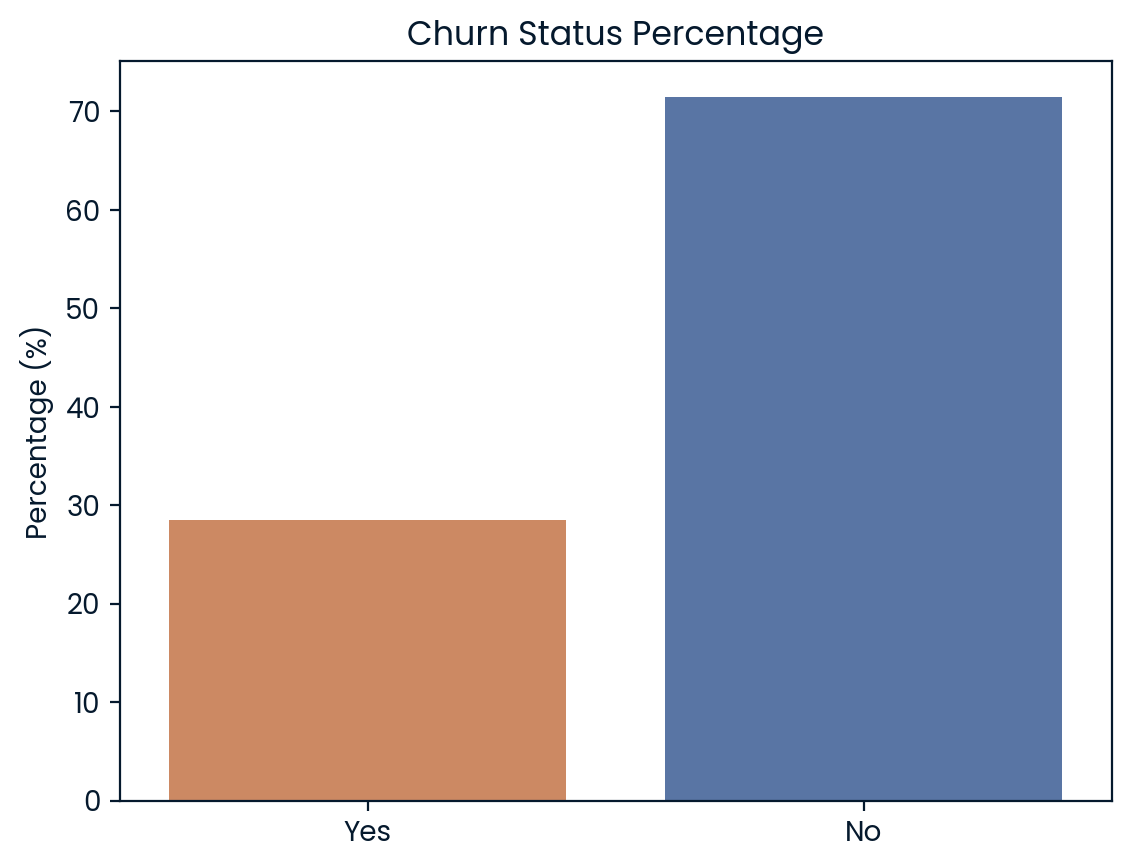

In [155]:
# countplot with percentage
chart01 = sns.countplot(
    x="churn_status", 
    data=account_info, 
    stat="percent", 
    hue="churn_status", 
    hue_order=['N', 'Y'],
    palette="deep"  
)

chart01.set_title("Churn Status Percentage")
chart01.set(xlabel='', ylabel='Percentage (%)')
chart01.set_xticklabels(["Yes", "No"])

#plt.savefig("chart01_churn_percentage.png")
plt.show()

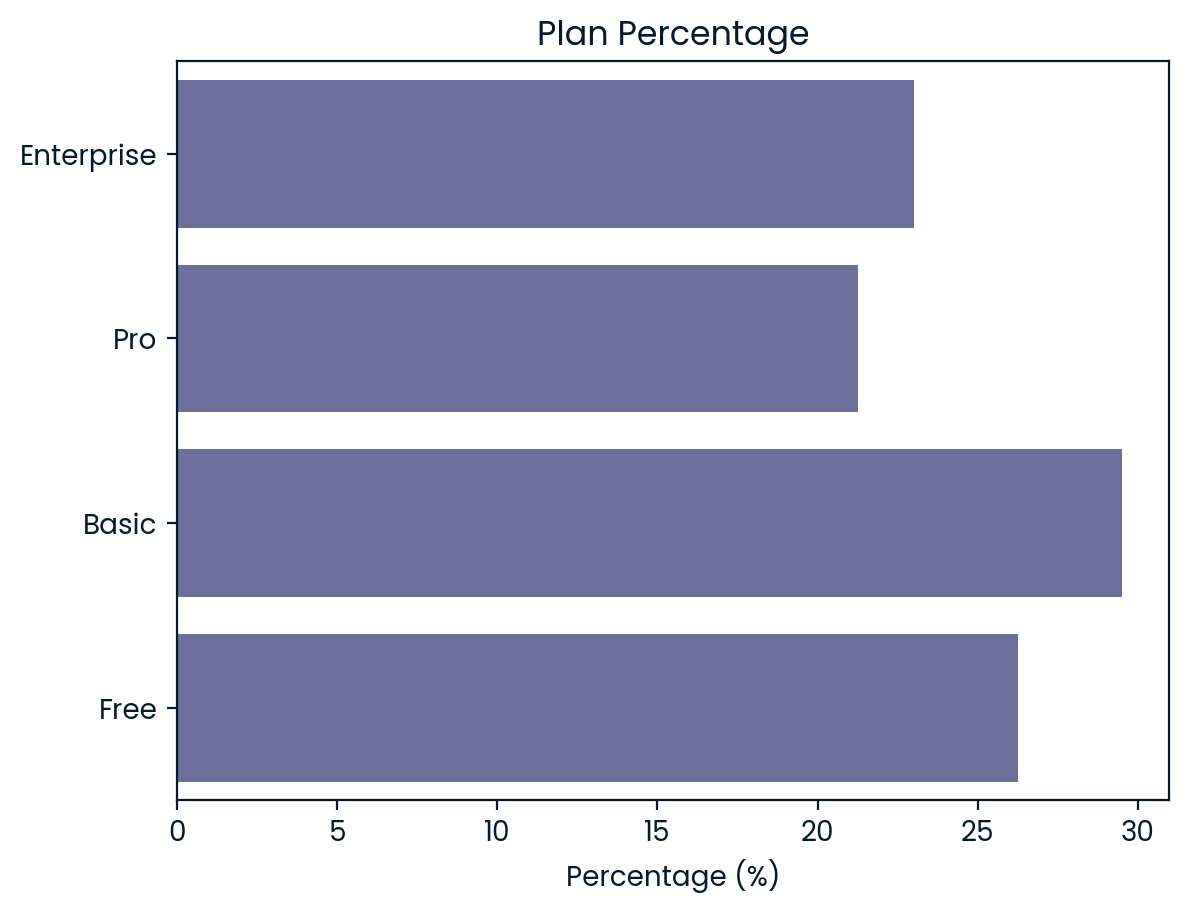

In [156]:
# countplot with plan type
chart02 = sns.countplot(y="plan", data=account_info, stat="percent", orient='h', order =['Enterprise', 'Pro', 'Basic', 'Free'])

chart02.set_title("Plan Percentage")
chart02.set(ylabel='', xlabel='Percentage (%)')

#plt.savefig("chart02_plan_percentage.png")
plt.show()

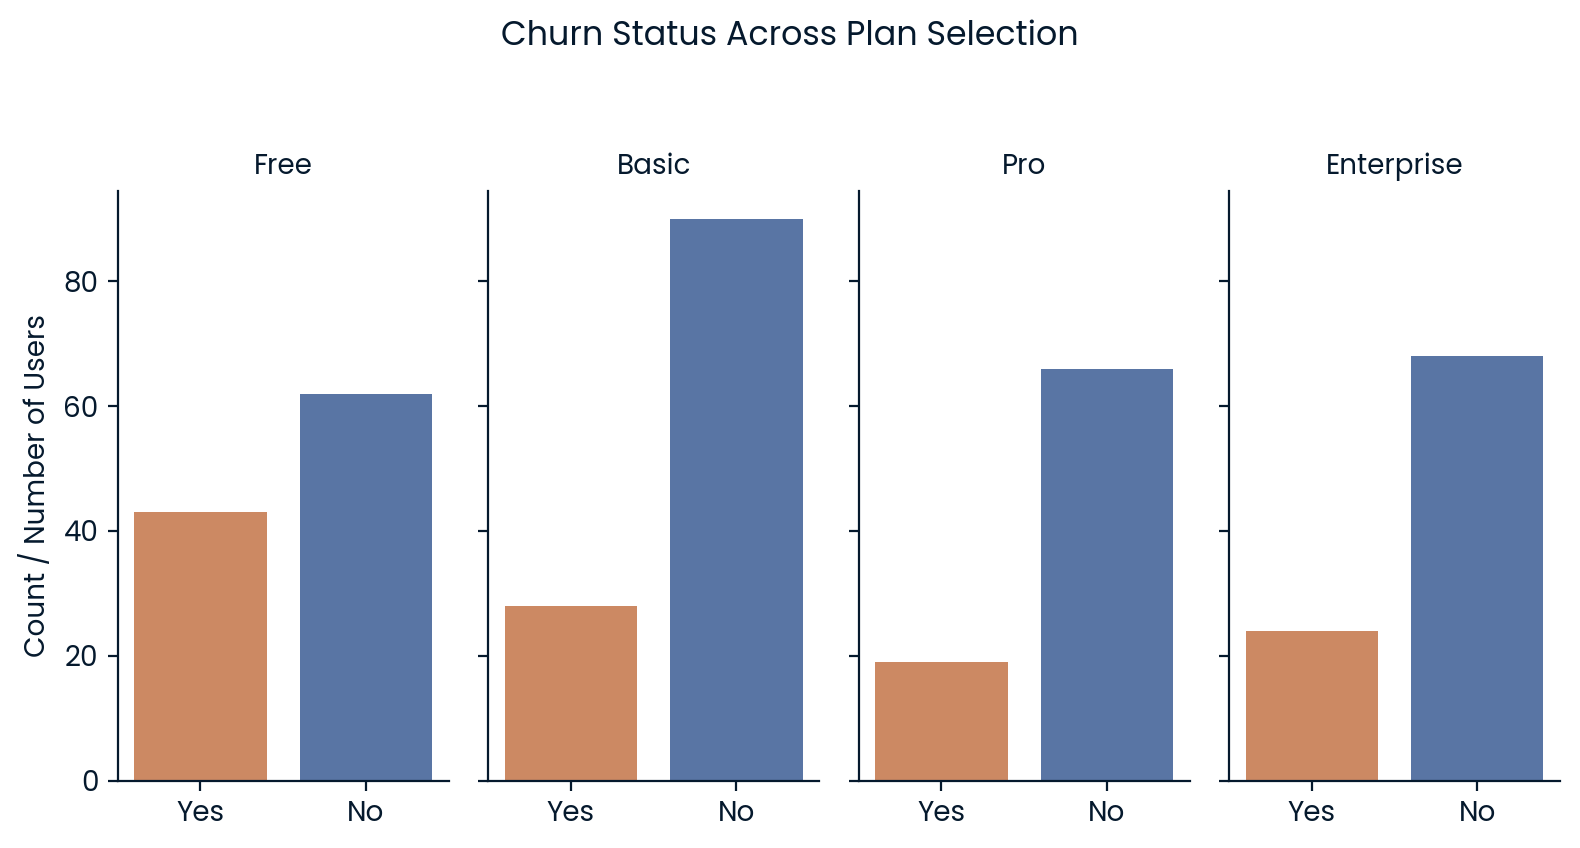

In [16]:
chart03 = sns.catplot(
    data=account_info, kind="count",
    x="churn_status", col="plan", 
    hue='churn_status', palette="deep", 
    hue_order=['N', 'Y'],
    height=4, aspect=.5, 
    col_order=['Free', 'Basic', 'Pro', 'Enterprise'], 
    legend=False
)
chart03.fig.suptitle("Churn Status Across Plan Selection", y=1.05)
chart03.set_titles("{col_name}")
chart03.set(ylabel="Count / Number of Users", xlabel="")
chart03.set_xticklabels(["Yes", "No"])

#plt.savefig("chart03_plan_churn.png")
plt.show()

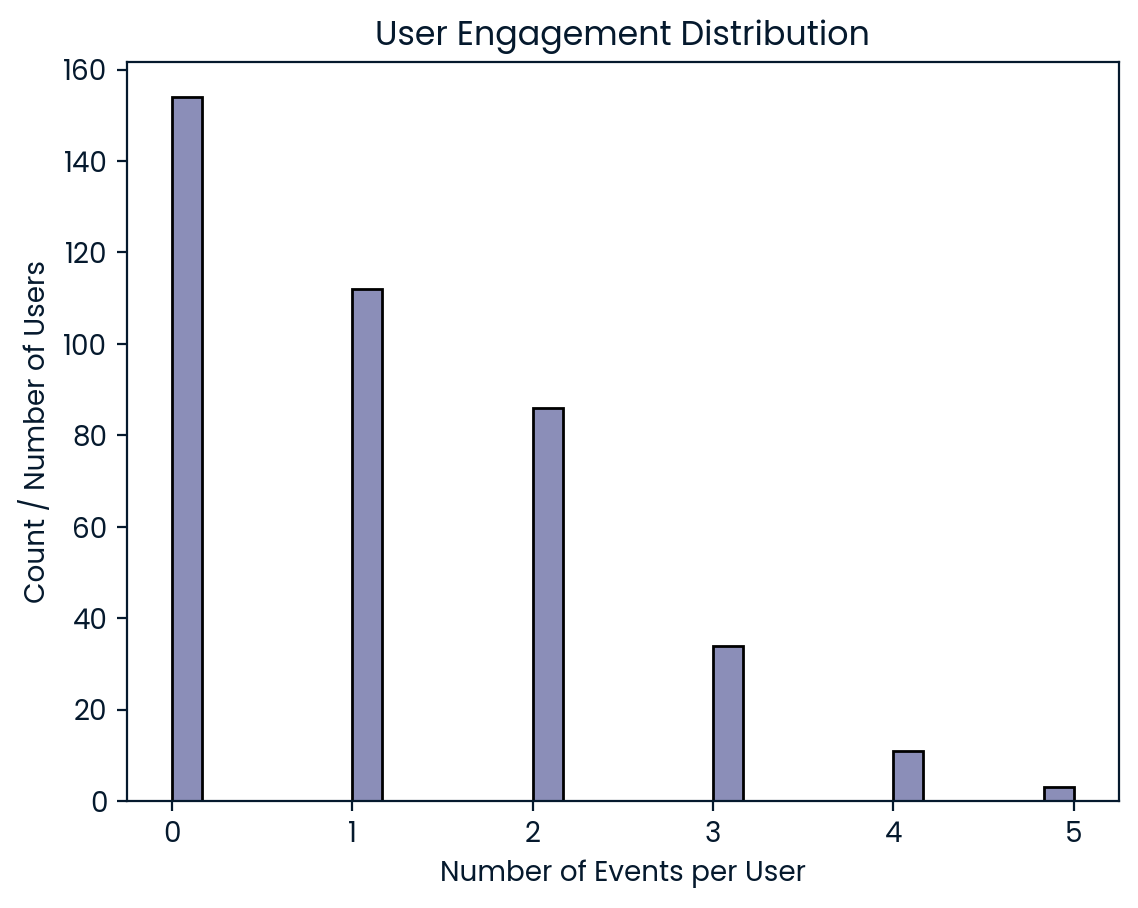

In [158]:
# histogram with engagement

chart04 = sns.histplot(data=engagement_full, x='event_count', bins=30)  
chart04.set(xlabel="Number of Events per User", ylabel="Count / Number of Users")
chart04.set_title("User Engagement Distribution")

#plt.savefig("chart04_user_engagement_dist.png")
plt.show()

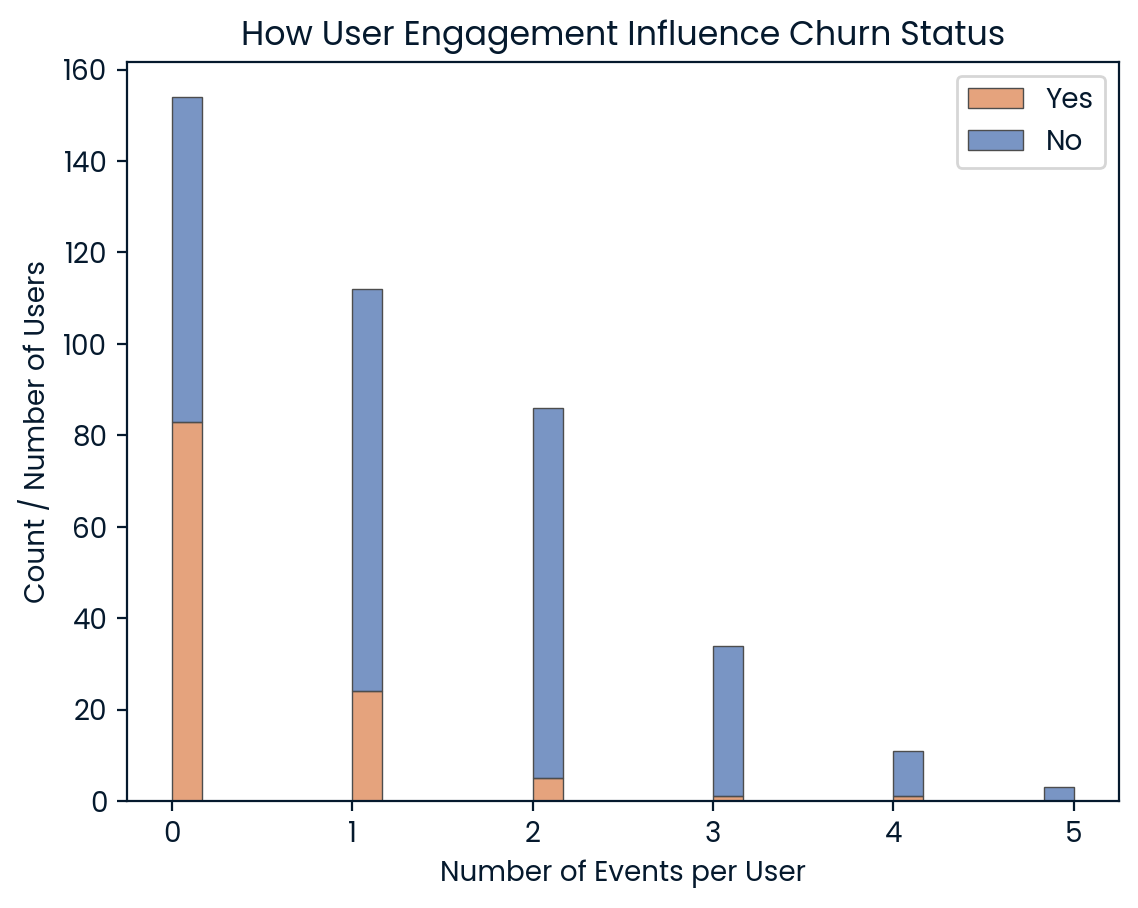

In [159]:
# hist engagement vs churn status
chart05 = sns.histplot(engagement_full, 
                       x= 'event_count', hue='churn_status', 
                       multiple='stack', bins=30,  edgecolor=".3", 
                       linewidth=.5, hue_order=['N', 'Y'], palette="deep"
                      )
chart05.set_title("How User Engagement Influence Churn Status")
chart05.set(xlabel="Number of Events per User", ylabel="Count / Number of Users")
plt.legend( labels=['Yes', 'No'])

#plt.savefig("chart05_user_engagement_churn.png")
plt.show()

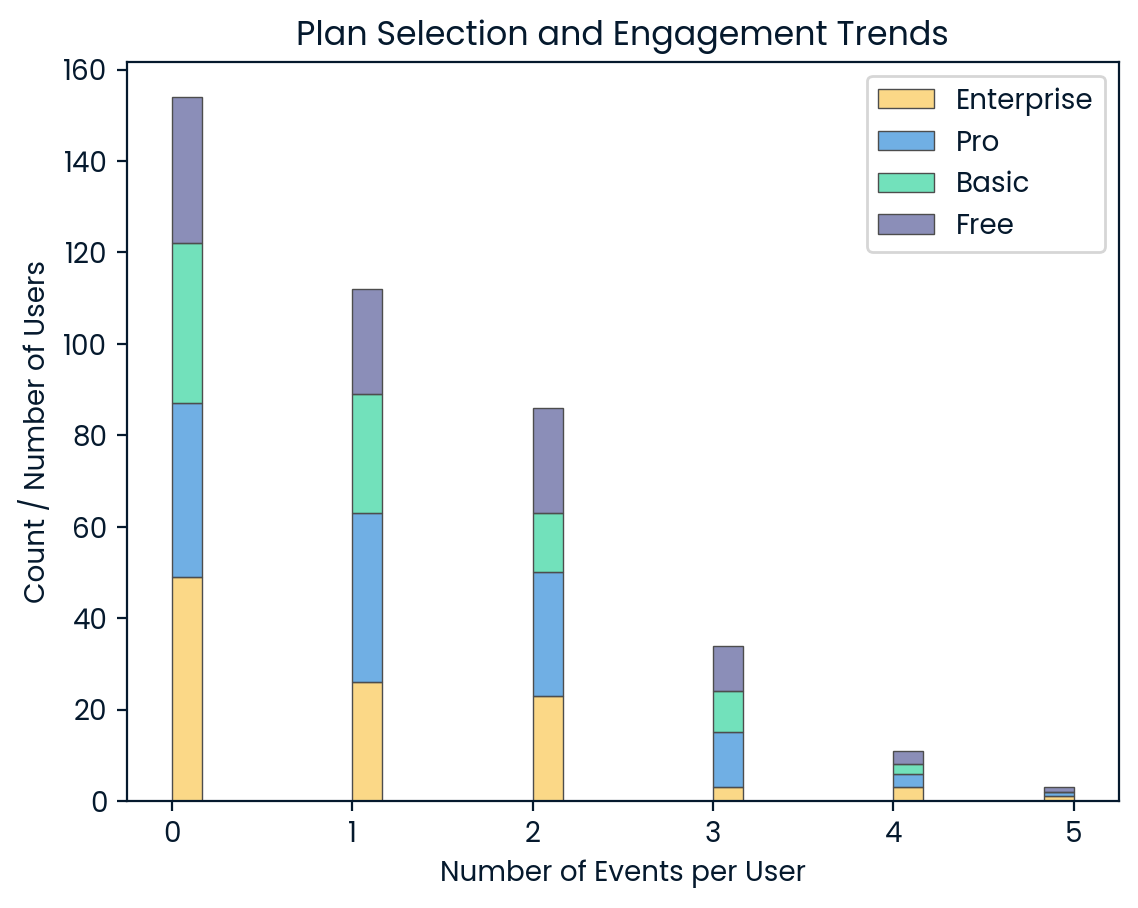

In [160]:
#histplot plan vs engagement
chart06 = sns.histplot(engagement_full, x='event_count', hue='plan', 
             multiple='stack', bins=30, 
             edgecolor=".3", linewidth=.5, 
             hue_order=['Enterprise', 'Pro', 'Basic', 'Free']
            )

chart06.set_title("Plan Selection and Engagement Trends")
chart06.set(xlabel="Number of Events per User", ylabel="Count / Number of Users")
plt.legend( labels=['Enterprise', 'Pro', 'Basic', 'Free'])

#plt.savefig("chart06_plan_user_engagement.png")
plt.show()

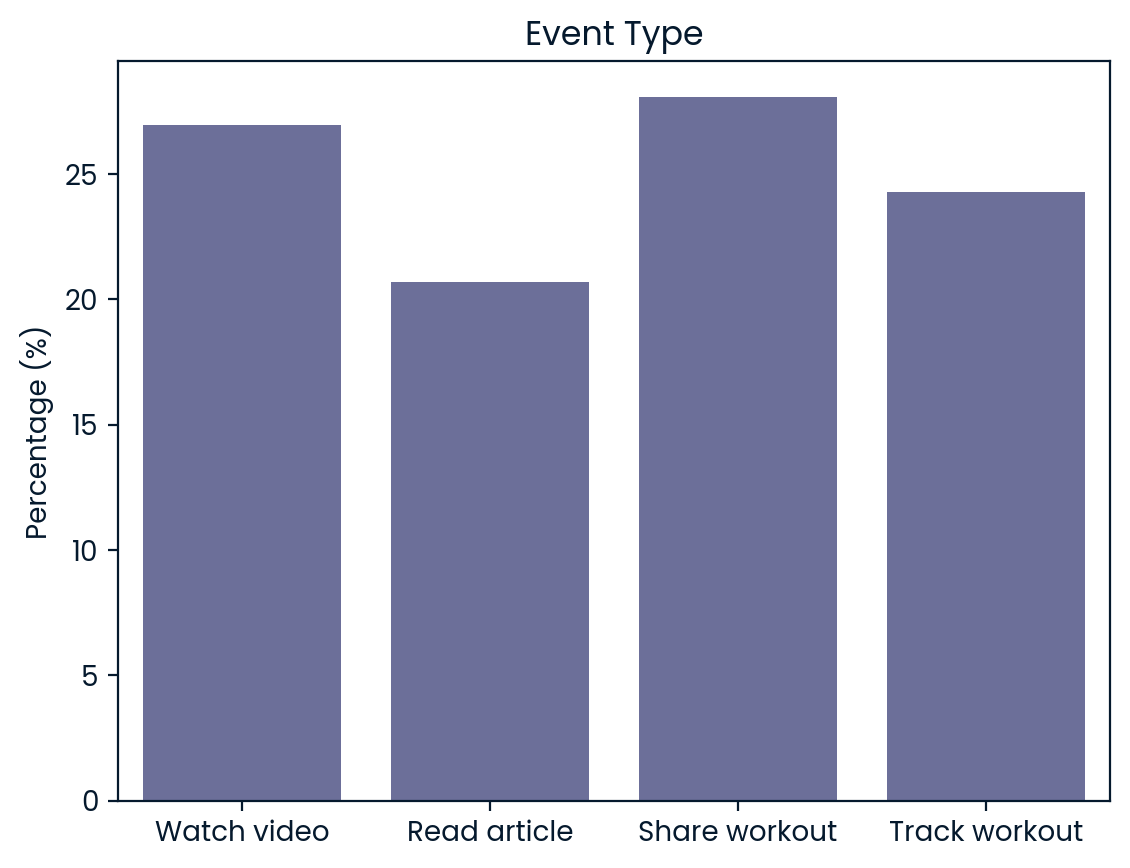

In [161]:
# countplot with topic
chart07 = sns.countplot(x="event_type", data=ua_churn, stat="percent")

chart07.set_title("Event Type")
chart07.set(xlabel='', ylabel='Percentage (%)')
chart07.set_xticklabels(['Watch video', 'Read article', 'Share workout', 'Track workout'])

#plt.savefig("chart07_event_type_percentage.png")
plt.show()

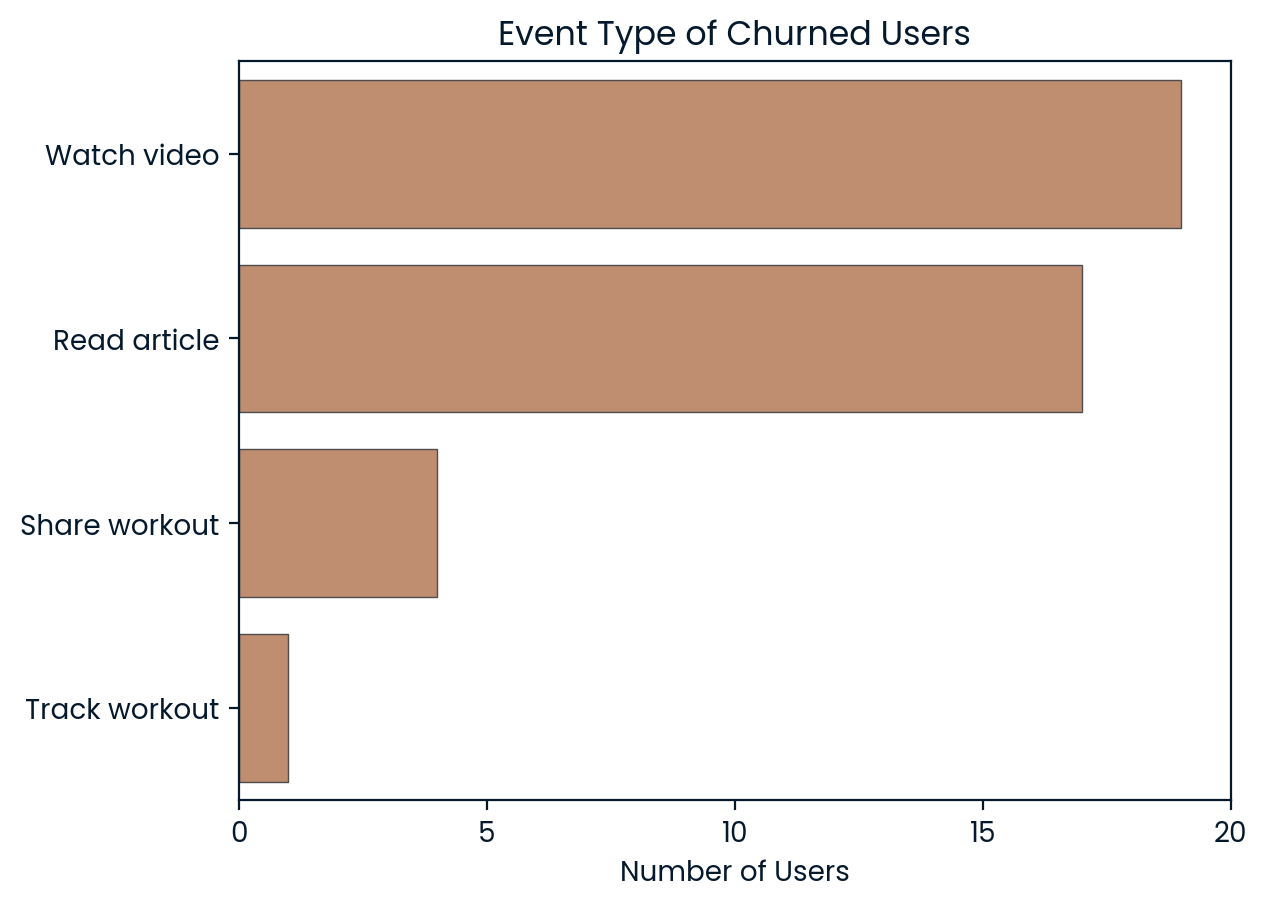

In [15]:
#countplot with event type churn yes user
chart08 = sns.countplot(
    data=ua_churn[ua_churn['churn_status']=='Y'], 
    y='event_type', 
    edgecolor=".3", 
    linewidth=.5, 
    orient='h',
    color="#cc8963", 
    order=['watch_video', 'read_article', 'share_workout', 'track_workout']
)
chart08.set_title("Event Type of Churned Users")
chart08.set(xlabel="Number of Users", ylabel="")
chart08.set(xticks=[0, 5, 10, 15, 20])
chart08.set_yticklabels(['Watch video', 'Read article', 'Share workout', 'Track workout'])

plt.savefig("chart08_event_type_churn_yes.png")
plt.show()

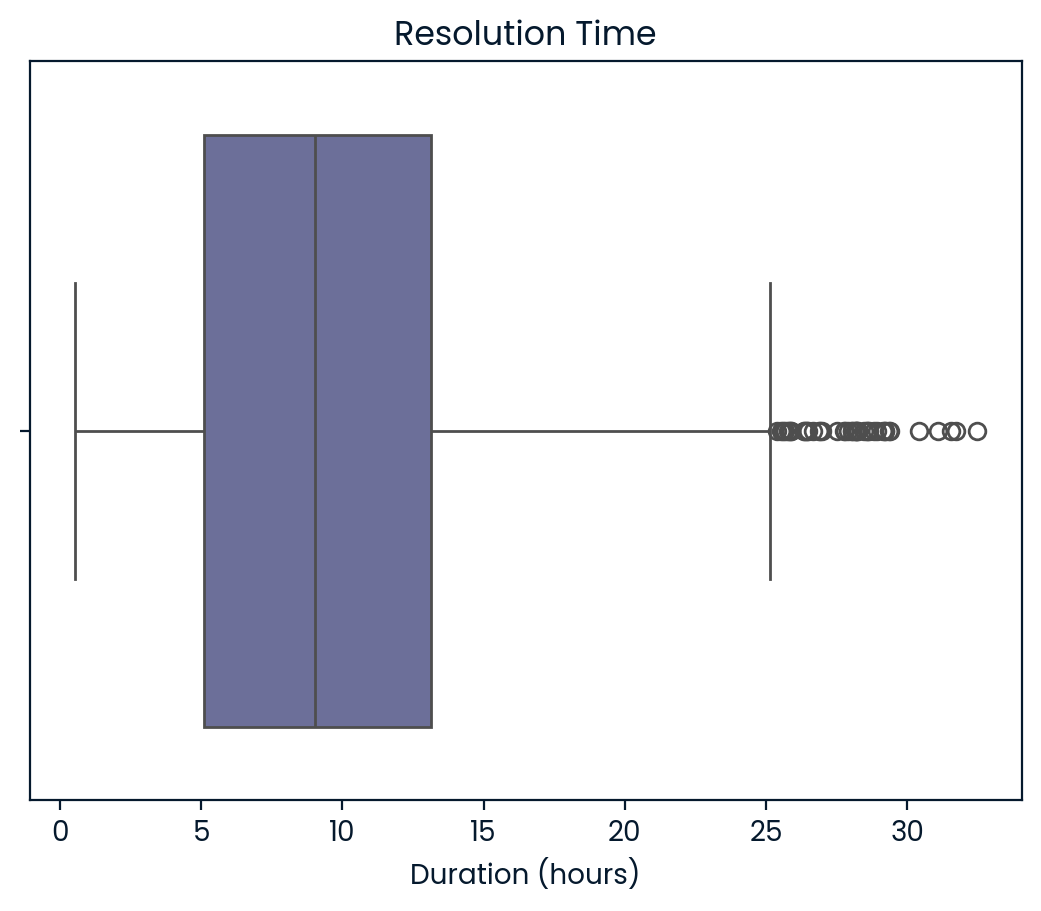

In [163]:
#boxplot with resolution time
chart09 = sns.boxplot(cs_churn, x='resolution_time_hours')
chart09.set_title("Resolution Time")
chart09.set(xlabel="Duration (hours)")

#plt.savefig("chart09_resolution_time.png")
plt.show()

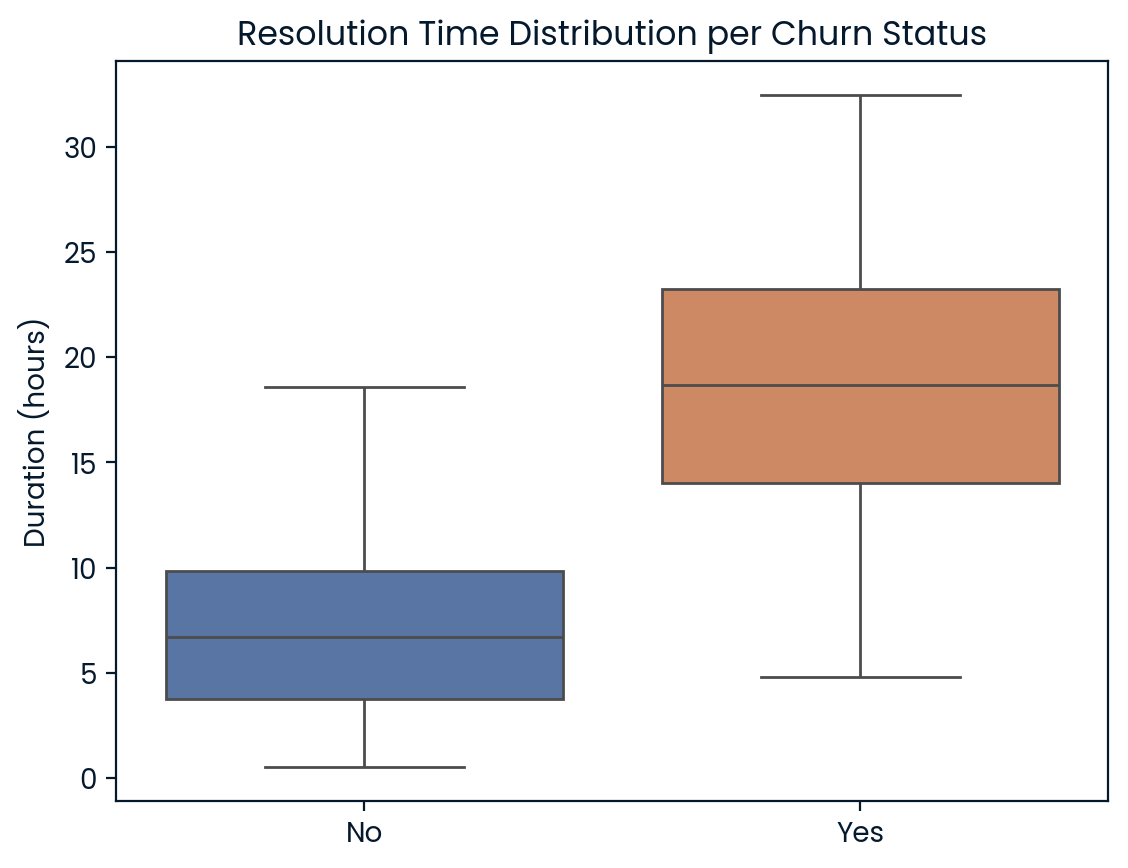

In [164]:
#boxplot with resolution time vs churn status
chart10 = sns.boxplot(cs_churn, y='resolution_time_hours', x='churn_status', hue='churn_status', hue_order=['N', 'Y'], palette="deep")
chart10.set_title("Resolution Time Distribution per Churn Status")
chart10.set(ylabel="Duration (hours)", xlabel="")
chart10.set_xticklabels(["No", "Yes"])

#plt.savefig("chart10_resolution_time_churn.png")
plt.show()

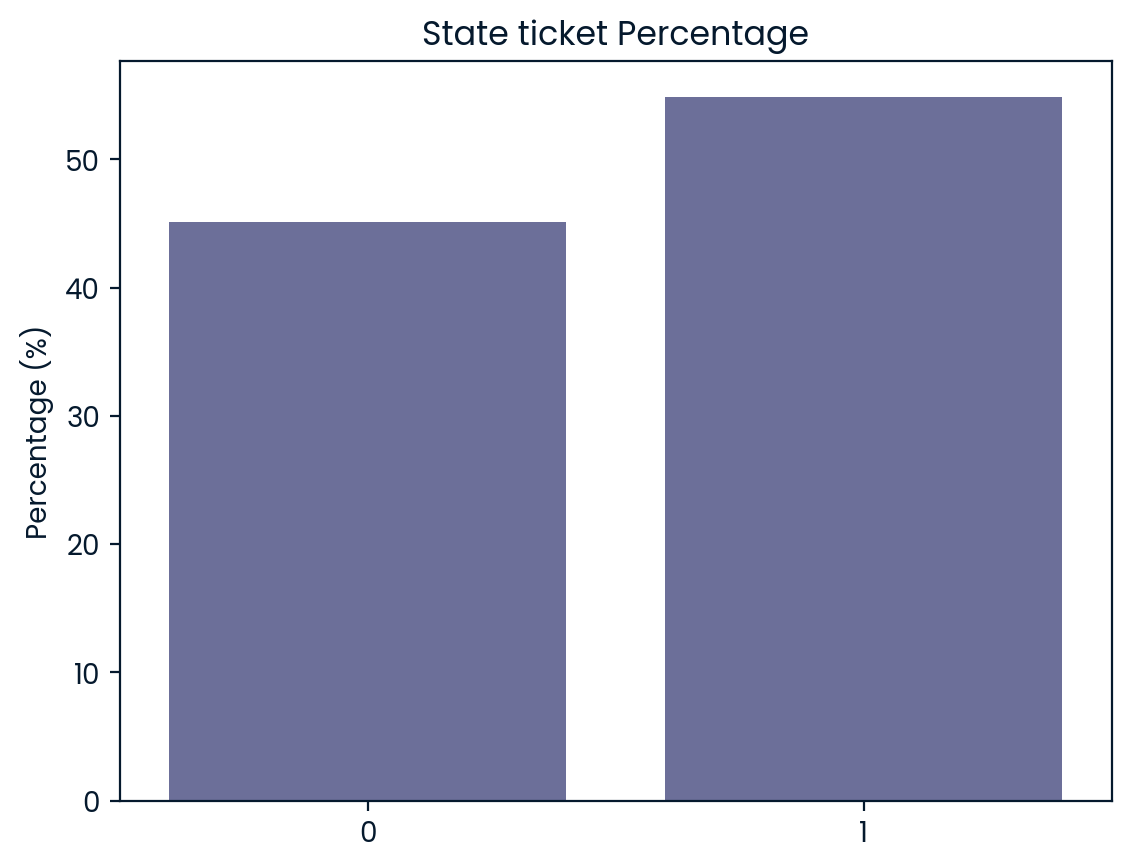

In [165]:
# countplot with state ticket
chart6 = sns.countplot(x="state_ticket", data=cs_churn, stat="percent")

chart6.set_title("State ticket Percentage")
chart6.set(xlabel='', ylabel='Percentage (%)')
#chart6.set_xticklabels(["Yes", "No"])

plt.show()

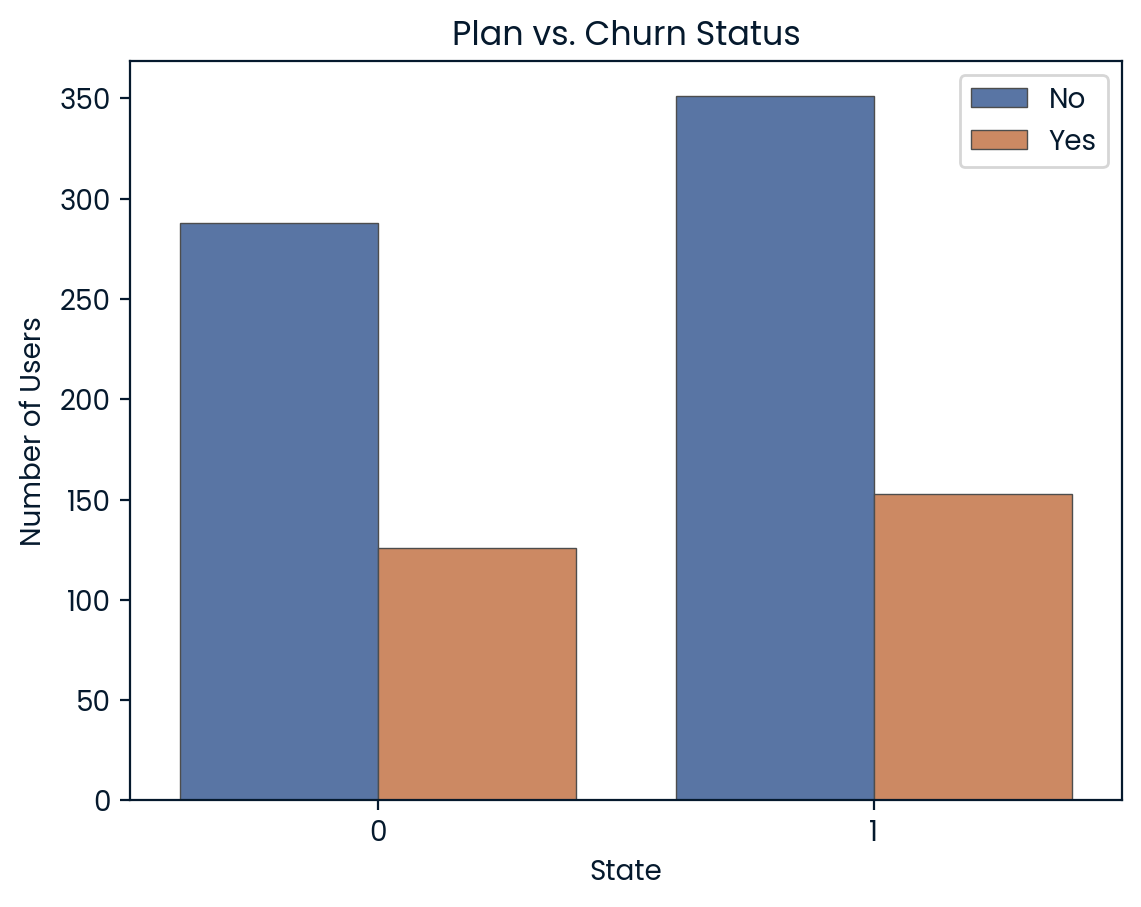

In [166]:
# countplot state ticket vs churn status
chart7 = sns.countplot(cs_churn, x= 'state_ticket', hue='churn_status',  edgecolor=".3", linewidth=.5, hue_order=['N', 'Y'], palette="deep")
chart7.set_title("Plan vs. Churn Status")
chart7.set(xlabel="State", ylabel="Number of Users")
plt.legend(labels = ['No', 'Yes'])
plt.show()

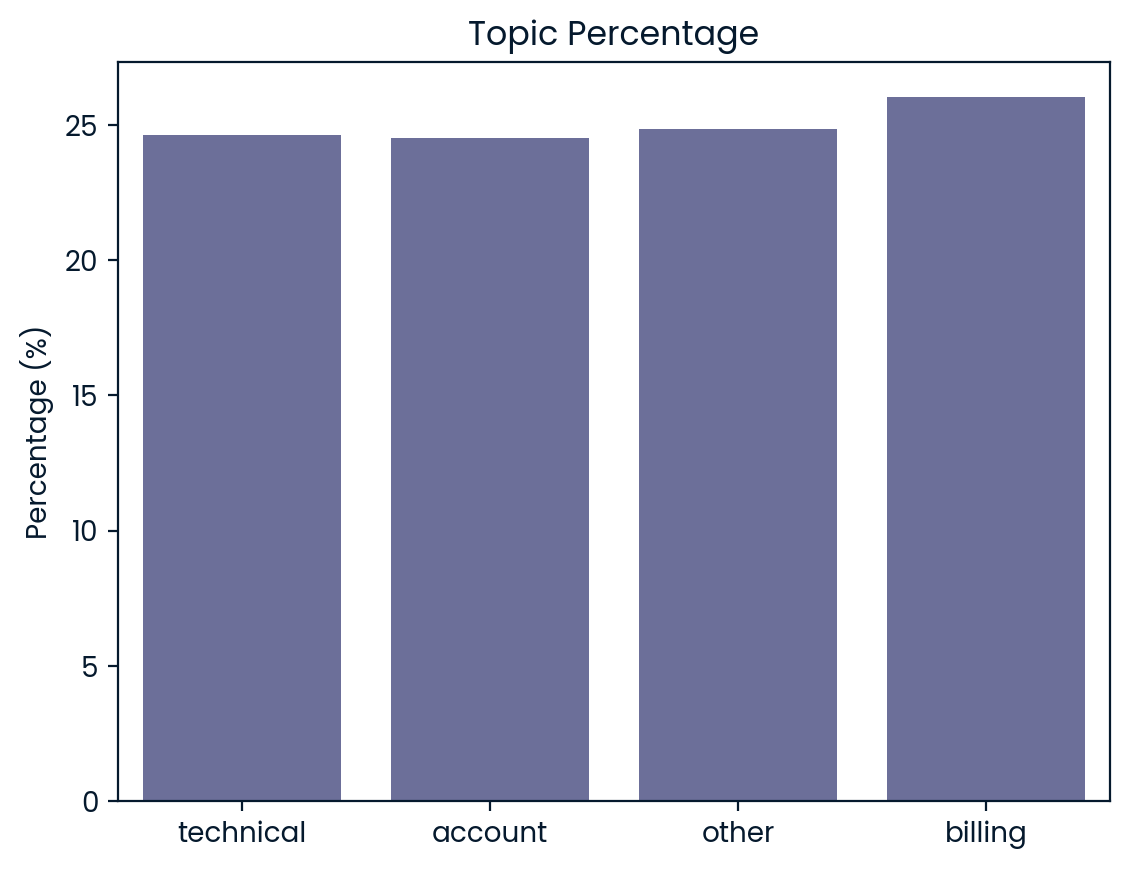

In [167]:
# countplot with topic
chart010 = sns.countplot(x="topic", data=cs_churn, stat="percent")

chart010.set_title("Topic Percentage")
chart010.set(xlabel='', ylabel='Percentage (%)')
#chart6.set_xticklabels(["Yes", "No"])

plt.show()

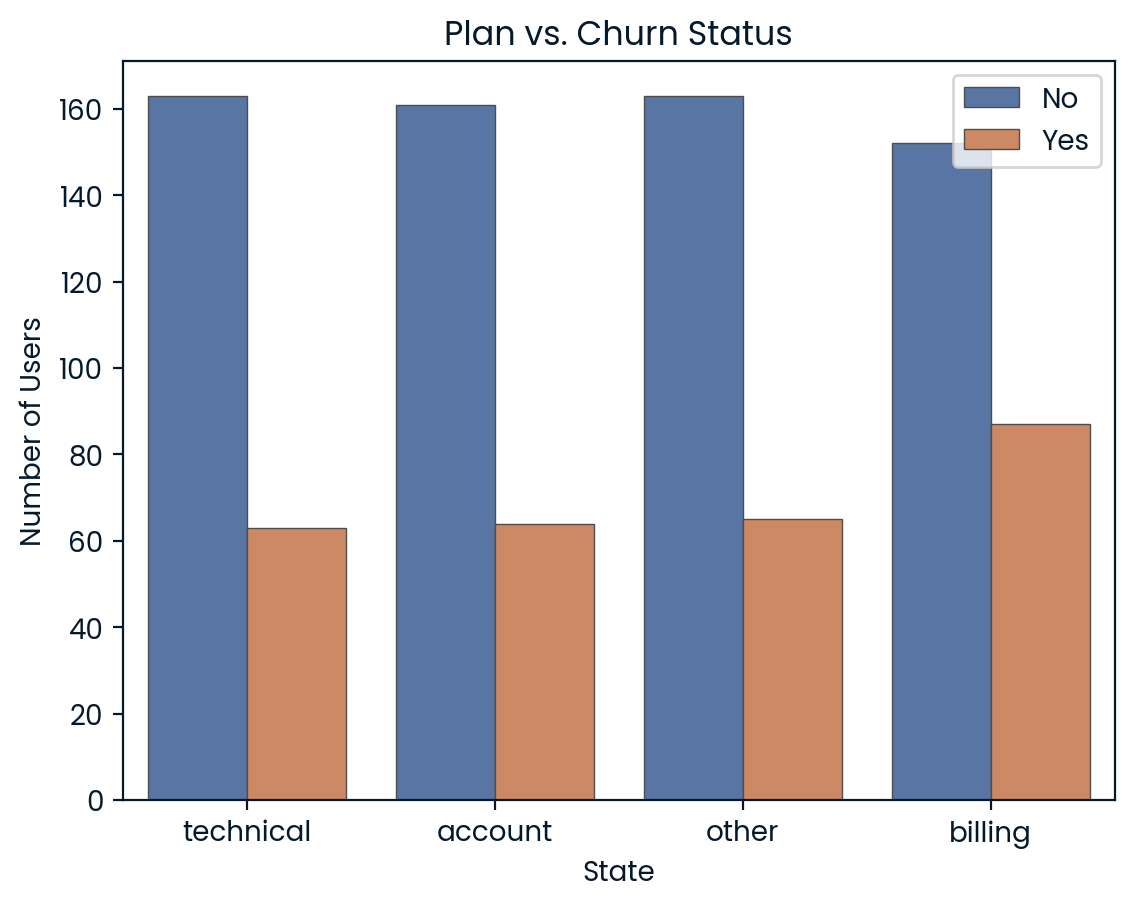

In [168]:
chart11 = sns.countplot(cs_churn, x= 'topic', hue='churn_status',  edgecolor=".3", linewidth=.5, hue_order=['N', 'Y'], palette="deep")
chart11.set_title("Plan vs. Churn Status")
chart11.set(xlabel="State", ylabel="Number of Users")
plt.legend(labels = ['No', 'Yes'])
plt.show()